# Proyecto: Modelo de Clasificación de Riesgo Crediticio

### Este notebook documenta el proceso de construcción de un modelo predictivo para identificar la probabilidad de incumplimiento de pago (mora). Utilizaremos un pipeline de Machine Learning que abarca desde el análisis exploratorio hasta la optimización de un modelo XGBoost.

#### Objetivo: Predecir si un cliente tendrá un retraso superior a 90 días en sus pagos en los próximos dos años.

In [3]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

# Configuración de constantes
RANDOM_STATE = 42
PALETTE = {"good": "#2ECC71", "bad": "#E74C3C", "neutral": "#3498DB"}

## 1. Obtención de Datos

### Generamos un dataset sintético. Este dataset contiene variables financieras como ingresos, edad y ratios de deuda.

In [4]:
from generate_data import generate_credit_data

df = generate_credit_data(n_samples=150_000, random_state=RANDOM_STATE)
print(f"Dataset cargado con {df.shape[0]} registros.")
df.head()

Dataset cargado con 150000 registros.


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,0.180323,52,0,0.560283,33639.219784,6,0,4,0,3.0,0
1,0.142926,43,0,0.356668,NaN,11,0,2,0,1.0,0
2,0.177569,50,0,0.255982,9774.766236,13,0,2,0,NaN,0
3,0.441123,36,1,0.362655,2495.959520,6,1,0,1,2.0,1
4,0.523671,26,0,0.337566,3628.188934,6,0,2,1,1.0,1


## 2. Análisis Exploratorio (EDA)

### Antes de modelar, debemos entender la distribución de nuestras clases. El desbalanceo es un factor crítico aquí: la mayoría de los clientes pagan a tiempo.

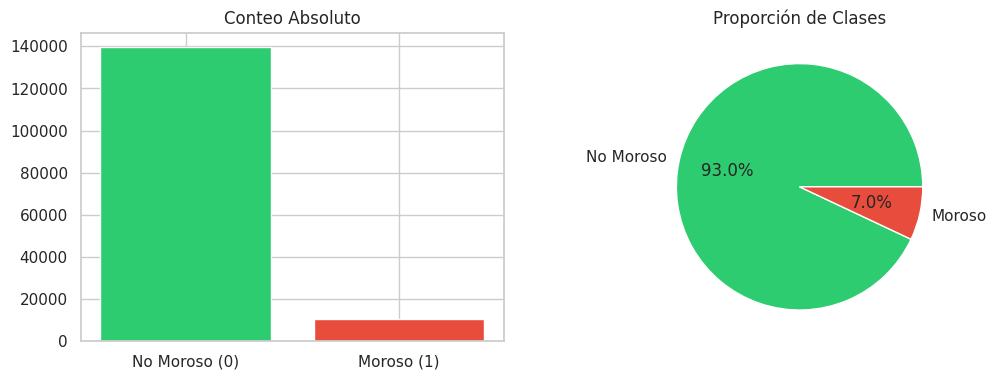

In [5]:
counts = df["SeriousDlqin2yrs"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["No Moroso (0)", "Moroso (1)"], counts.values, color=[PALETTE["good"], PALETTE["bad"]])
ax[0].set_title("Conteo Absoluto")

ax[1].pie(counts, labels=["No Moroso", "Moroso"], autopct="%1.1f%%", colors=[PALETTE["good"], PALETTE["bad"]])
ax[1].set_title("Proporción de Clases")
plt.show()

## 3. Ingeniería de Características y Limpieza

### Los modelos de Machine Learning se benefician de datos limpios y variables con significado financiero. Realizaremos:

### Imputación: Llenar valores faltantes con la mediana.

### Tratamiento de Outliers: Truncar valores extremos (Capping) al percentil 99.

### Creación de Ratios: Generamos variables como debt_income_ratio y total_past_due.

In [7]:
df_clean = df.copy()

# Imputación por mediana
for col in ["MonthlyIncome", "NumberOfDependents"]:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median)
    print(f"      {col}: imputado con mediana = {median:.1f}")

# Outliers: cap en percentil 99 para variables continuas
cap_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
for col in cap_cols:
    cap = df_clean[col].quantile(0.99)
    n_capped = (df_clean[col] > cap).sum()
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"      {col}: {n_capped:,} valores truncados en {cap:.2f}")

# Feature engineering — features adicionales con significado financiero
df_clean["debt_income_ratio"] = (
    df_clean["DebtRatio"] * df_clean["MonthlyIncome"] /
    (df_clean["MonthlyIncome"] + 1)
)
df_clean["total_past_due"] = (
    df_clean["NumberOfTime30-59DaysPastDueNotWorse"] +
    df_clean["NumberOfTime60-89DaysPastDueNotWorse"] +
    df_clean["NumberOfTimes90DaysLate"]
)
df_clean["utilization_per_line"] = (
    df_clean["RevolvingUtilizationOfUnsecuredLines"] /
    (df_clean["NumberOfOpenCreditLinesAndLoans"] + 1)
)
df_clean["income_per_dependent"] = (
    df_clean["MonthlyIncome"] /
    (df_clean["NumberOfDependents"] + 1)
)



      MonthlyIncome: imputado con mediana = 6001.1
      NumberOfDependents: imputado con mediana = 1.0
      RevolvingUtilizationOfUnsecuredLines: 1,500 valores truncados en 0.89
      DebtRatio: 1,500 valores truncados en 0.72
      MonthlyIncome: 1,500 valores truncados en 24530.57


## 4. Manejo de Desbalanceo (SMOTE)

### Como los "Morosos" son solo el 7%, el modelo podría ignorarlos. Utilizaremos SMOTE para crear ejemplos sintéticos de la clase minoritaria y equilibrar el entrenamiento.

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_clean.drop("SeriousDlqin2yrs", axis=1)
y = df_clean["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f"Distribución original: {np.bincount(y_train)}")
print(f"Distribución post-SMOTE: {np.bincount(y_res)}")

Distribución original: [111600   8400]
Distribución post-SMOTE: [111600 111600]


## 5. Entrenamiento del Modelo y Evaluación Avanzada

### Utilizamos XGBoost, un algoritmo de Gradient Boosting altamente eficiente. Evaluamos el modelo no solo por su precisión, sino por su capacidad de distinguir entre clases usando la curva AUC-ROC.

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Entrenar modelo
model = XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X_res, y_res)

# Evaluación
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.40).astype(int)

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

AUC-ROC Score: 0.9844
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     27900
           1       0.61      0.92      0.74      2100

    accuracy                           0.95     30000
   macro avg       0.80      0.94      0.86     30000
weighted avg       0.97      0.95      0.96     30000



## 6. ¿Qué factores pesan más?

### Finalmente, visualizamos qué variables son las más importantes para que el modelo decida si alguien es un riesgo.

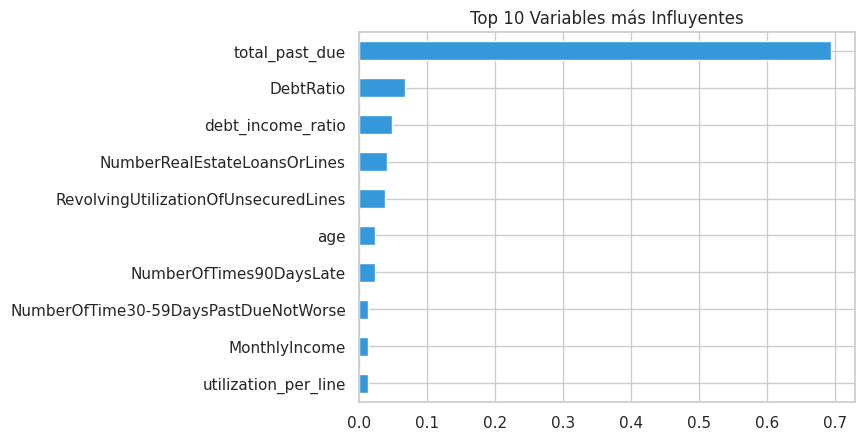

In [10]:
# Gráfica de importancia de features
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
fi.tail(10).plot(kind='barh', color=PALETTE["neutral"])
plt.title("Top 10 Variables más Influyentes")
plt.show()